# Chapter 5.2.3: Cubical Cavity

## How you actually should implement it: Julia style implementation
In this example, we compute the resonance frequencies of a PEC cuboid cavity. Recall the analytic formula [(4.40), Harrington]
\begin{equation}
\left(f_\mathrm{r}\right)_{mnp} = \frac{1}{2\sqrt{\varepsilon \mu}} \sqrt{\left(\frac{m}{a}\right)^2 + \left(\frac{n}{b}\right)^2 + \left(\frac{p}{c}\right)^2}
\end{equation}
Below, the function `f_r`implements the above function, and `list_resonancefrequencies` generates a sorted list of these resonance frequencies together with a string that provides the mode index.

In [12]:
using Printf

function f_r(m, n, p; a=1, b=1, c=1, ε0 = 8.8541878e-12, µ0  = 4e-7 * π)
    return 1/(2*sqrt(ε0*µ0)) * sqrt((m/a)^2 + (n/b)^2 + (p/c)^2)
end

function list_resonancefrequencies(maxfreq; maxint=2)
    ret = []
    for m=0:maxint
        for n=0:maxint
            for p=0:maxint
                if (m==0 && n==0) || (m==0 && p==0) || (n==0 && p==0)
                    continue
                end
                resfreq = f_r(m, n, p; a=a, b=b, c=c)
                resfreq > maxfreq && continue
                strresfreq = @sprintf("%i%i%i: %.2e", m, n, p, resfreq)
                push!(ret, (resfreq, strresfreq))
            end
        end
    end
    return sort!(ret)
end

list_resonancefrequencies (generic function with 1 method)

In [5]:
using LinearAlgebra
function simulate_cavity_forloops(a::F, b::F, c::F) where F
    # Physical constants
    ε0 = F(8.8541878e-12)          # Permittivity of vacuum
    µ0 = F(4e-7 * π)            # Permeability of vacuum
    c0 = F(299792458)             # Speed of light in vacuum

    # Parameter initiation
    Lx = a; Ly = b; Lz = c # Cavity dimensions in meters
    Nx = 25; Ny = 20; Nz = 15 # Number of cells along each axis
    Cx = Nx / Lx                 # Inverse cell dimensions
    Cy = Ny / Ly
    Cz = Nz / Lz
    Nt = 8192                    # Number of time steps
    Dt = 1/(c0*norm([Cx Cy Cz])) # Time step

    # Allocate field matrices
    Ex = zeros(F, Nx  , Ny+1, Nz+1)
    Ey = zeros(F, Nx+1, Ny  , Nz+1)
    Ez = zeros(F, Nx+1, Ny+1, Nz  )
    Hx = zeros(F, Nx+1, Ny  , Nz  )
    Hy = zeros(F, Nx  , Ny+1, Nz  )
    Hz = zeros(F, Nx  , Ny  , Nz+1)

    # Allocate time signals
    Et = zeros(F, Nt, 3)

    # Initiate fields with noise (except on the boundary)
    Ex[ :  , 2:Ny, 2:Nz] = rand(F, Nx  , Ny-1, Nz-1) .- F(0.5)
    Ey[2:Nx,  :  , 2:Nz] = rand(F, Nx-1, Ny  , Nz-1) .- F(0.5)
    Ez[2:Nx, 2:Ny,  :  ] = rand(F, Nx-1, Ny-1, Nz  ) .- F(0.5)

    # Time stepping
    for n = 1:Nt

        # Update H everywhere
        for i = 1:Nx+1
            for j = 1:Ny
                for k = 1:Nz
                    Hx[i, j, k] = Hx[i, j, k] + (Dt/µ0)*
                    ( (Ey[i, j,  k + 1] - Ey[i, j,  k])*Cz - (Ez[i, j + 1, k] - Ez[i, j, k])*Cy )
                end
            end
        end
        
        for i = 1:Nx
            for j = 1:Ny+1
                for k = 1:Nz
                    Hy[i, j, k] = Hy[i, j, k] + (Dt/µ0)*
                    ( (Ez[i + 1, j,  k] - Ez[i, j,  k])*Cx - (Ex[i, j, k + 1] - Ex[i, j, k])*Cz )
                end
            end
        end
        
        for i = 1:Nx
            for j = 1:Ny
                for k = 1:Nz+1
                    Hz[i, j, k] = Hz[i, j, k] + (Dt/µ0)*
                    ( (Ex[i, j + 1,  k] - Ex[i, j,  k])*Cy - (Ey[i + 1, j, k] - Ey[i, j, k])*Cx )
                end
            end
        end

        # Update E everywhere except on boundary
        for i = 1:Nx
            for j = 2:Ny
                for k = 2:Nz
                    Ex[i, j, k] = Ex[i, j, k] + (Dt /ε0) * 
                    ( (Hz[i, j, k] - Hz[i, j - 1, k])*Cy - (Hy[i, j, k] - Hy[i, j, k - 1])*Cz)
                end
            end
        end
        
        for i = 2:Nx
            for j = 1:Ny
                for k = 2:Nz
                    Ey[i, j, k] = Ey[i, j, k] + (Dt /ε0) * 
                    ( (Hx[i, j, k] - Hx[i, j, k - 1])*Cz - (Hz[i, j, k] - Hz[i - 1, j, k])*Cx)
                end
            end
        end
        
        for i = 2:Nx
            for j = 2:Ny
                for k = 1:Nz
                    Ez[i, j, k] = Ez[i, j, k] + (Dt /ε0) * 
                    ( (Hy[i, j, k] - Hy[i - 1, j, k])*Cx - (Hx[i, j, k] - Hx[i, j - 1, k])*Cy)
                end
            end
        end

        # Sample the electric field at chosen points
        Et[n,:] = [Ex[4,4,4] Ey[4,4,4] Ez[4,4,4]]
    end

    time = Dt*Nt

    f  = (1/time)*(range(F(0), stop=F(Nt-1), length=Nt) |> collect)
    return f, Et[:, 1] + Et[:, 2] + Et[:, 3]
end

simulate_cavity_forloops (generic function with 1 method)

### Unit test

In [6]:
using Test

F = Float32

a = F(.05)
b = F(.04)
c = F(.03)

@time f, Et = simulate_cavity_forloops(a, b, c)

@test eltype(f) == F
@test eltype(Et) == F

  3.447135 seconds (1.07 M allocations: 53.870 MiB, 1.17% gc time, 36.73% compilation time)


Test Passed

### Simulate Julia style

In [7]:
@time f, Et = simulate_cavity_forloops(a, b, c)

  2.133634 seconds (8.23 k allocations: 1.247 MiB)


(Float32[0.0, 3.1692858f7, 6.3385716f7, 9.507858f7, 1.2677143f8, 1.5846429f8, 1.9015715f8, 2.2185f8, 2.5354286f8, 2.852357f8  …  2.5931096f11, 2.5934266f11, 2.5937435f11, 2.5940604f11, 2.5943774f11, 2.5946943f11, 2.5950111f11, 2.5953282f11, 2.595645f11, 2.595962f11], Float32[-1.1328583, -1.0645523, -0.22427607, -0.668037, -1.1848693, -0.90923595, -0.74296975, -0.7112101, -0.80492544, -0.84399194  …  -0.3577661, -0.6597811, -1.1805199, -0.67661905, -0.38898045, -0.9930104, -1.2005926, -0.67095673, -0.509301, -0.86573184])

**Moral:** Notice the simulation time: using for loops in Julia is not only increasing readability, but also speeding up the simulation!

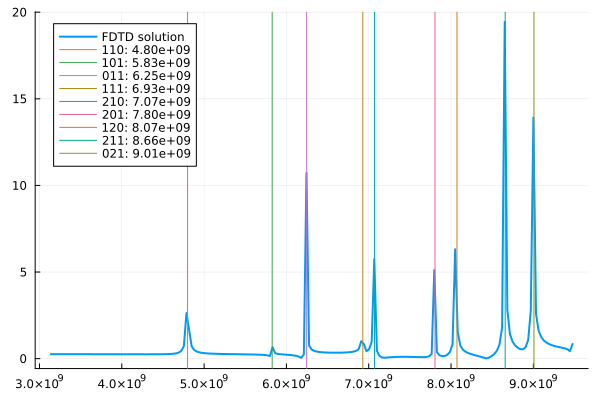

In [13]:
using FFTW
using Plots

F = fft(Et)

plt = plot(f[100:300], abs.(F)[100:300], label="FDTD solution", legend=:topleft, linewidth=2)
for (resfreq, strresfreq) in sort!(list_resonancefrequencies(f[300]))
    vline!(plt, [resfreq], label=strresfreq)
end
display(plt) # When we manipulate a plot in a for loop, we need to enforce explicitly to display the result

**Caveat:** Of course, allows double check the results. A faster simulation time is worth nothing if the result is wrong...

## How not to implement it: Matlab style

The following is a translation of the Matlab code from the textbook. Similar to the textbook, we use the `diff` to compute the finite differences. The alternative, simply using for loops, is demonstrated later on.

**WARNING:** For those of you, who have never used Matlab, note that in Matlab for loops are extreme slow. Thus people try to vectorize their algorithms, which make them actually hard to read (at least for me). You can code Matlab-style in Julia, however, I would not recommend to do so. The code will become less readable, and, as we actually will see, not even faster.

In [11]:
using Plots
using LinearAlgebra

function simulate_cavity(a::F, b::F, c::F) where F
    # Physical constants
    ε0 = F(8.8541878e-12)          # Permittivity of vacuum
    µ0 = F(4e-7 * π)            # Permeability of vacuum
    c0 = F(299792458)             # Speed of light in vacuum

    # Parameter initiation
    Lx = a; Ly = b; Lz = c # Cavity dimensions in meters
    Nx = 25; Ny = 20; Nz = 15 # Number of cells along each axis
    Cx = Nx / Lx                 # Inverse cell dimensions
    Cy = Ny / Ly
    Cz = Nz / Lz
    Nt = 8192                    # Number of time steps
    Dt = 1/(c0*norm([Cx Cy Cz])) # Time step
    
    # Allocate field matrices
    Ex = zeros(F, Nx  , Ny+1, Nz+1)
    Ey = zeros(F, Nx+1, Ny  , Nz+1)
    Ez = zeros(F, Nx+1, Ny+1, Nz  )
    Hx = zeros(F, Nx+1, Ny  , Nz  )
    Hy = zeros(F, Nx  , Ny+1, Nz  )
    Hz = zeros(F, Nx  , Ny  , Nz+1)

    # Allocate time signals
    Et = zeros(F, Nt, 3)

    # Initiate fields with noise (except on the boundary)
    Ex[ :  , 2:Ny, 2:Nz] = rand(F, Nx  , Ny-1, Nz-1) .- F(0.5)
    Ey[2:Nx,  :  , 2:Nz] = rand(F, Nx-1, Ny  , Nz-1) .- F(0.5)
    Ez[2:Nx, 2:Ny,  :  ] = rand(F, Nx-1, Ny-1, Nz  ) .- F(0.5)

    # Time stepping
    for n = 1:Nt

      # Update H everywhere
      Hx = Hx + (Dt/µ0)*(diff(Ey, dims=3)*Cz - diff(Ez, dims=2)*Cy)
      Hy = Hy + (Dt/µ0)*(diff(Ez, dims=1)*Cx - diff(Ex, dims=3)*Cz)
      Hz = Hz + (Dt/µ0)*(diff(Ex, dims=2)*Cy - diff(Ey, dims=1)*Cx)

      # Update E everywhere except on boundary
      Ex[:,2:Ny,2:Nz] = Ex[:,2:Ny,2:Nz] + (Dt /ε0) * 
          (diff(Hz[:,:,2:Nz], dims=2)*Cy - diff(Hy[:,2:Ny,:], dims=3)*Cz)
      Ey[2:Nx,:,2:Nz] = Ey[2:Nx,:,2:Nz] + (Dt /ε0) * 
          (diff(Hx[2:Nx,:,:], dims=3)*Cz - diff(Hz[:,:,2:Nz], dims=1)*Cx)
      Ez[2:Nx,2:Ny,:] = Ez[2:Nx,2:Ny,:] + (Dt /ε0) * 
          (diff(Hy[:,2:Ny,:], dims=1)*Cx - diff(Hx[2:Nx,:,:], dims=2)*Cy)

      # Sample the electric field at chosen points
      Et[n,:] = [Ex[4,4,4] Ey[4,4,4] Ez[4,4,4]]
    end

    time = Dt*Nt

    # Collect converts the range expression into a vector
    f  = (1/time)*(range(start=F(0), stop=F(Nt-1), length=Nt) |> collect)
    return f, Et[:, 1] + Et[:, 2] + Et[:, 3]
end

simulate_cavity (generic function with 1 method)

In [ ]:
a = .05
b = .04
c = .03

@time f, Et = simulate_cavity(a, b, c)

We just plot a part of the spectrum here. Feel free to play around with what part of the spectrum is plotted.

In [ ]:
using FFTW

F = fft(Et)

plt = plot(f[100:300], abs.(F)[100:300], label="FDTD solution", legend=:topleft, linewidth=2)
for (resfreq, strresfreq) in sort!(list_resonancefrequencies(f[300]))
    vline!(plt, [resfreq], label=strresfreq)
end
display(plt) # When we manipulate a plot in a for loop, we need to enforce explicitly to display the result

### Unit test
Test that our implementatio works allows with single precision.

In [ ]:
using Test

F = Float32

a = F(.05)
b = F(.04)
c = F(.03)

@time f, Et = simulate_cavity(a, b, c)

@test eltype(f) == F
@test eltype(Et) == F